In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models
     

In [40]:
df = pd.read_csv('mnist_train.csv')
df_test = pd.read_csv('mnist_test.csv')

In [41]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
df.shape

(60000, 785)

In [43]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [45]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [46]:
X_train = df.drop('label', axis=1).values
y_train = df['label'].values
X_test = df_test.drop('label', axis=1).values
y_test = df_test['label'].values

In [47]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [48]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [49]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [50]:
perceptron = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(10, activation='softmax')
])

In [51]:
perceptron.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [52]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=100, batch_size=256, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/100


I0000 00:00:1773080869.006384   23410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_839239__.15


229/235 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3790 - loss: 1.9244

I0000 00:00:1773080871.318039   23411 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_839239__.15


235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5829 - loss: 1.5921 - val_accuracy: 0.7897 - val_loss: 1.1135
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8069 - loss: 0.9615 - val_accuracy: 0.8378 - val_loss: 0.8069
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8353 - loss: 0.7625 - val_accuracy: 0.8551 - val_loss: 0.6766
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8486 - loss: 0.6649 - val_accuracy: 0.8650 - val_loss: 0.6039
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8565 - loss: 0.6057 - val_accuracy: 0.8715 - val_loss: 0.5565
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8628 - loss: 0.5653 - val_accuracy: 0.8777 - val_loss: 0.5231
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8678 - loss: 0.5356 - val_accuracy: 0.8798 - val_loss: 0.4975
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8709 - loss: 0.5128 - val_accuracy: 0.884

In [53]:
acc_percp = perceptron.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_percp

0.9172000288963318

# ANN

In [54]:
ann = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

In [55]:
ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [56]:
history_ann = ann.fit(X_train_img, y_train_cat, epochs=100, batch_size=256, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/100


I0000 00:00:1773080970.318046   23408 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_955125__.19


227/235 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7805 - loss: 0.7371

I0000 00:00:1773080974.128511   23410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_955125__.19


235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.8924 - loss: 0.3736 - val_accuracy: 0.9519 - val_loss: 0.1596
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9621 - loss: 0.1275 - val_accuracy: 0.9644 - val_loss: 0.1104
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9750 - loss: 0.0829 - val_accuracy: 0.9733 - val_loss: 0.0907
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9817 - loss: 0.0593 - val_accuracy: 0.9768 - val_loss: 0.0762
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9729 - val_loss: 0.0853
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9769 - val_loss: 0.0748
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9918 - loss: 0.0271 - val_accuracy: 0.9766 - val_loss: 0.0864
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9924 - loss: 0.0243 - val_accuracy: 0.97

In [57]:
acc_ann = ann.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.9839000105857849

In [58]:
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [59]:
cnn = Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation='relu',padding='same'),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [60]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history_cnn = cnn.fit(X_train_cnn, y_train_cat, epochs=500, batch_size=256, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/500


I0000 00:00:1773081084.800170   23410 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1071265__.36


234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7668 - loss: 0.7056

I0000 00:00:1773081091.172343   23407 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1071265__.36


235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8983 - loss: 0.3226 - val_accuracy: 0.9835 - val_loss: 0.0487
Epoch 2/500
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9786 - loss: 0.0745 - val_accuracy: 0.9904 - val_loss: 0.0302
Epoch 3/500
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9847 - loss: 0.0541 - val_accuracy: 0.9900 - val_loss: 0.0341
Epoch 4/500
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9876 - loss: 0.0426 - val_accuracy: 0.9921 - val_loss: 0.0255
Epoch 5/500
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9901 - loss: 0.0335 - val_accuracy: 0.9927 - val_loss: 0.0249
Epoch 6/500
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9912 - loss: 0.0300 - val_accuracy: 0.9925 - val_loss: 0.0245
Epoch 7/500
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9923 - loss: 0.0267 - val_accuracy: 0.9933 - val_loss: 0.0198
Epoch 8/500
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9936 - loss: 0.0216 - val_accurac

In [ ]:
acc_cnn = cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)[1]
acc_cnn

0.9939000010490417

# Save Models for Deployment

In [ ]:
import os

os.makedirs('models', exist_ok=True)

perceptron.save('models/perceptron_model.h5')
ann.save('models/ann_model.h5')
cnn.save('models/cnn_model.h5')

print("All models saved to 'models/' folder:")
print(f"  Perceptron accuracy : {acc_percp*100:.2f}%")
print(f"  ANN accuracy        : {acc_ann*100:.2f}%")
print(f"  CNN accuracy        : {acc_cnn*100:.2f}%")


All models saved to 'models/' folder:
  Perceptron accuracy : 91.60%
  ANN accuracy        : 98.62%
  CNN accuracy        : 99.39%


In [ ]:
def plot_training(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

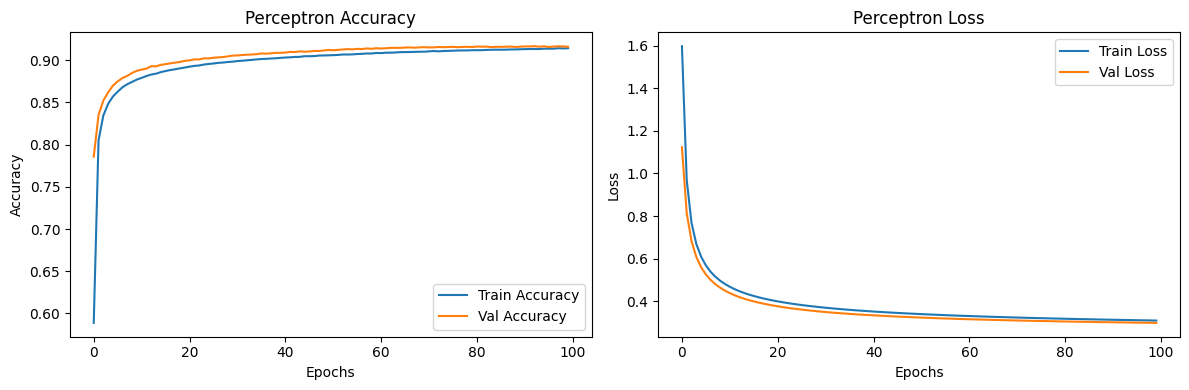

In [ ]:
plot_training(history_percp, 'Perceptron')

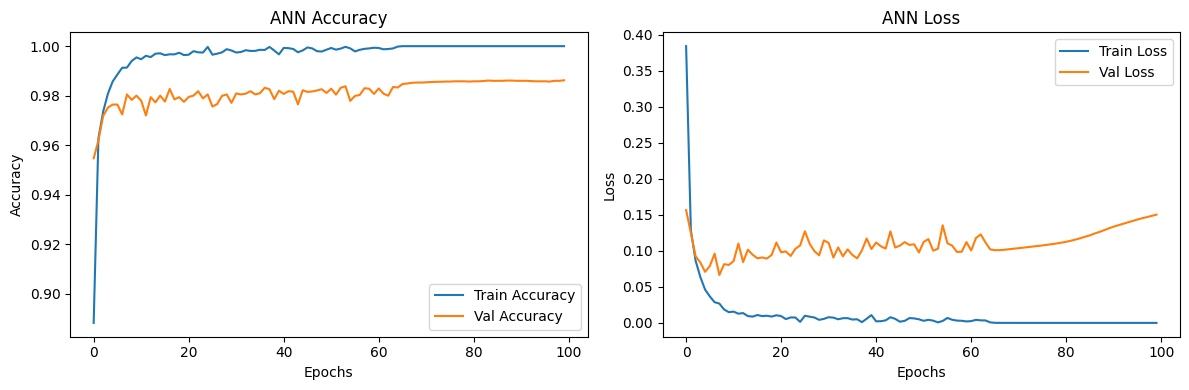

In [ ]:
plot_training(history_ann, 'ANN')

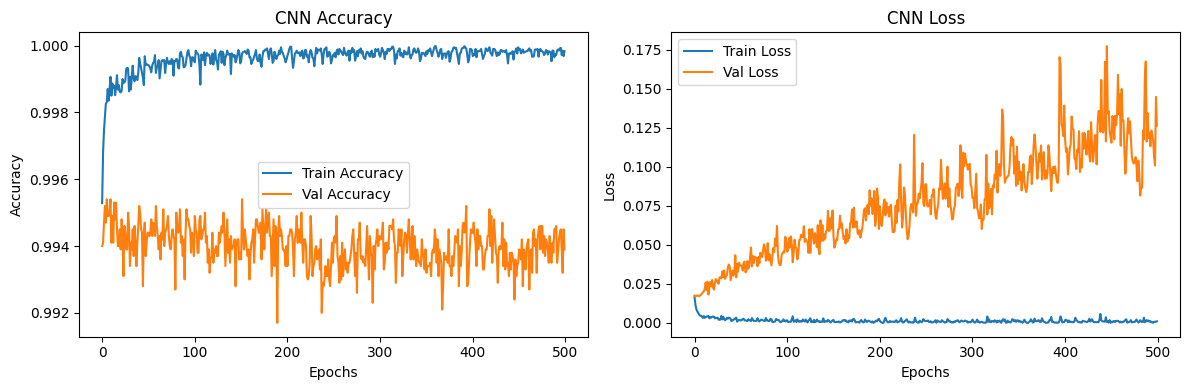

In [ ]:
plot_training(history_cnn, 'CNN')

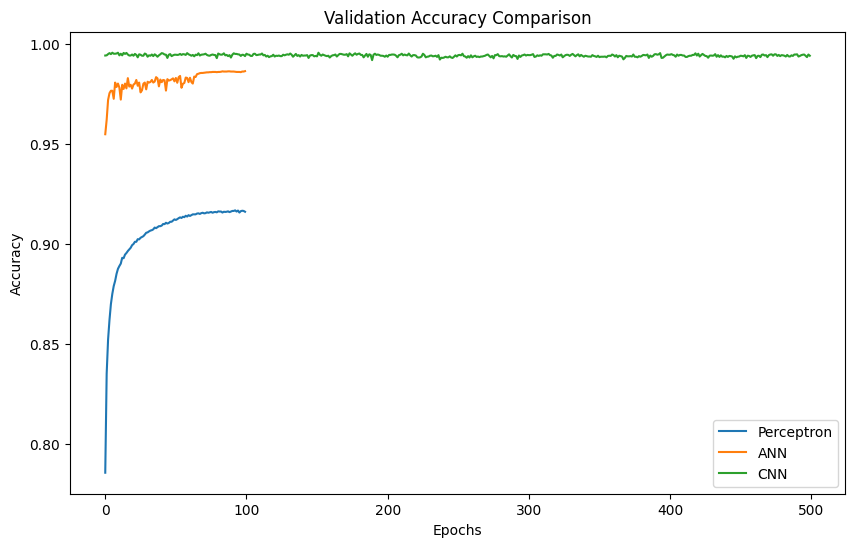

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history_percp.history['val_accuracy'], label='Perceptron')
plt.plot(history_ann.history['val_accuracy'], label='ANN')
plt.plot(history_cnn.history['val_accuracy'], label='CNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()


In [ ]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n = 5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap='gray')
        plt.axis('off')
        plt.title(f'True: {y_true[idx]}')
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == 'CNN' else X[idx].reshape(1, 28, 28))) for model, name in zip(models, model_names)]
        plt.subplot(2, n, i+1+n)
        plt.axis('off')
        plt.title('\n'.join(f'{n}: {p}' for n, p in zip(model_names, preds)))

    plt.tight_layout()
    plt.show()
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


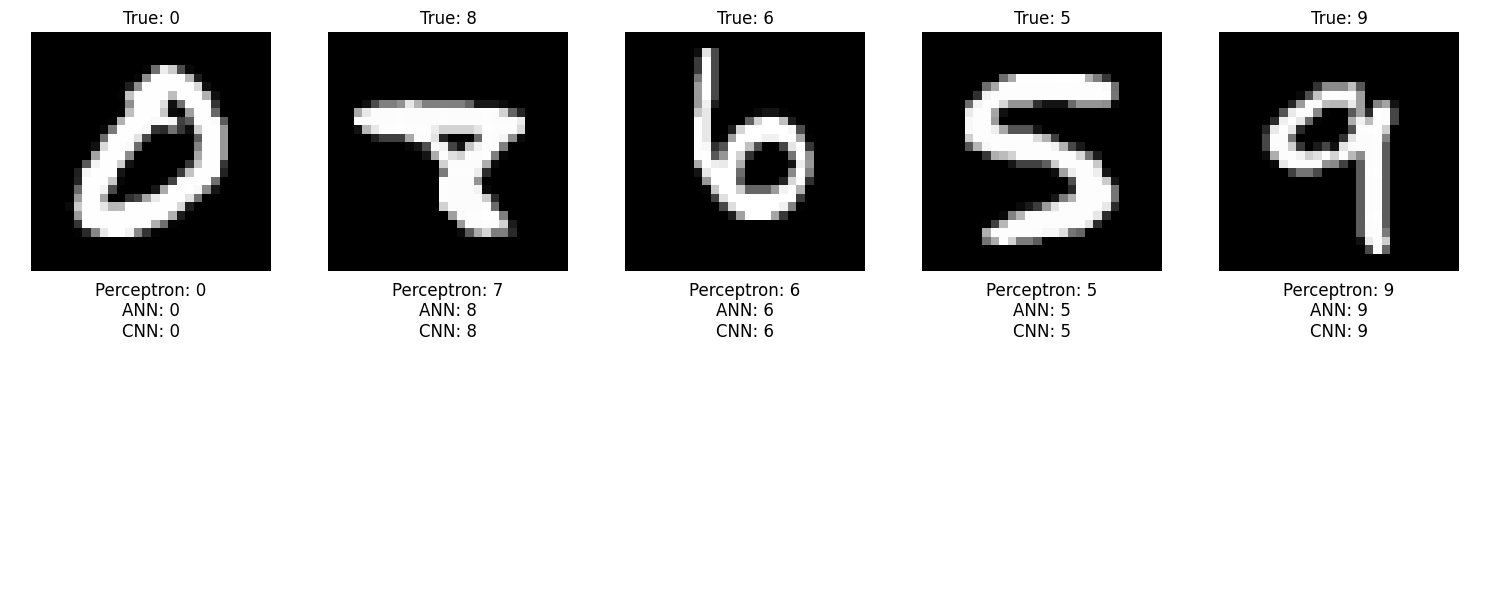

In [ ]:
show_side_by_side([perceptron, ann, cnn], ['Perceptron', 'ANN', 'CNN'], X_test_img, X_test_cnn, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


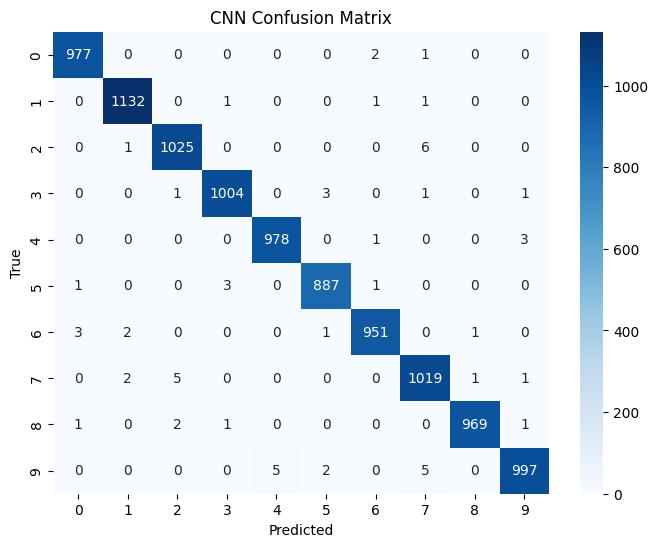

In [ ]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

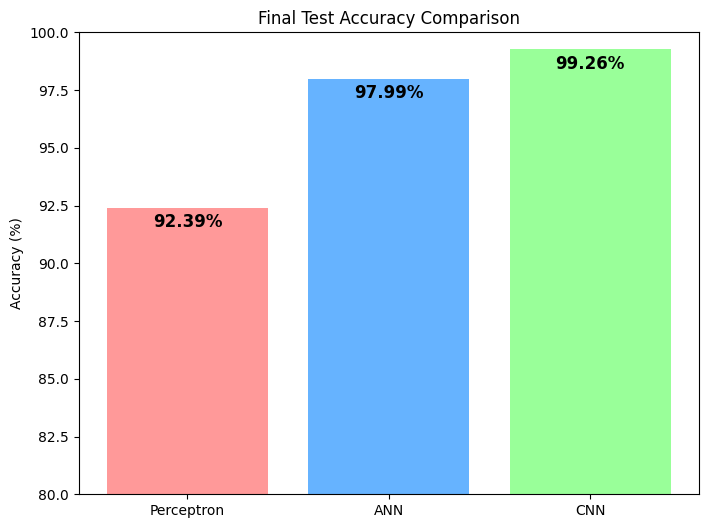

In [ ]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()